# **Aula Guiada - Aula 8**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ry4n-felinto/impytech_2026/blob/main/arquivos/aula_08/aula08_notebook_guiado.ipynb)

 - **Professor:** Pedro Alberti 
    - al.pedro.alberti@impatech.edu.br

 - **Monitores:**
   - Bianca Zavadisk
      - al.bianca.abreu@impatech.edu.br
   - Bruno Pereira
      - al.bruno.paula@impatech.edu.br
   - Cristiane Sampaio
      - al.cristiane.sampaio@impatech.edu.br
   - Gustavo Cardoso 
      - al.gustavo.cardoso@impatech.edu.br
 
 ## **Machine Learning: da Regressão Linear aos Conceitos Fundamentais**

---

### O que você vai aprender hoje

**Parte 1 — Programação Orientada a Objetos (POO)**
- O que é uma *classe* e por que ela é útil
- Propriedades (atributos) e métodos
- Encapsulamento
- Herança e polimorfismo

**Parte 3 — Regressão Linear: a porta de entrada para Machine Learning**
- Ideia por trás da regressão linear e ajuste com `scikit-learn`
- Ajustando o modelo com `scikit-learn`
- Como interpretar coeficiente, intercepto e R²
- A função de custo: "treinar" é otimizar
- O resumo estatístico completo (`statsmodels`)



---
# Parte 1 — Programação Orientada a Objetos (POO)

## Por que POO? Uma analogia com o prontuário

Imagine que você precisa guardar as informações de um paciente: nome, idade, peso, altura, resultados de exames... Uma forma "ingênua" seria criar uma variável para cada coisa:

```python
nome_paciente1 = "Pedro Alberti"
idade_paciente1 = 54
peso_paciente1 = 72.0
# ... e agora repita tudo para o paciente 2, 3, 4 ...
```

Isso vira um caos rapidamente. E se você tiver 500 pacientes? E se, além de *guardar* os dados, você quiser *calcular* o IMC de cada um?

A **Programação Orientada a Objetos** resolve isso com uma ideia simples: agrupar, numa mesma "caixinha", os **dados** (as informações) e as **ações** (o que dá para fazer com esses dados). Essa caixinha é o **objeto**.

Pense num prontuário: ele contém os dados do paciente **e** define o que se pode fazer com ele (registrar um exame, calcular um índice). Uma **classe** é o *modelo* do prontuário em branco; cada **objeto** é um prontuário preenchido de um paciente específico.


## 2.1 Conceito de classe

Vamos criar nossa primeira classe: um modelo para representar um **paciente**.

- `class Paciente:` — declara a classe (o "molde").
- `def __init__(self, ...):` — é o **construtor**: define o que acontece quando um novo paciente é criado e quais dados ele guarda.
- `self` — é uma referência ao **próprio objeto**. Sempre que quisermos guardar ou acessar um dado *daquele* paciente, usamos `self.`.


In [ ]:
class Paciente:
    def __init__(self, nome, idade, peso, altura):
        self.nome = nome        # atributo: nome do paciente
        self.idade = idade      # atributo: idade em anos
        self.peso = peso        # atributo: peso em kg
        self.altura = altura    # atributo: altura em metros

# Criando (instanciando) objetos a partir do molde:
paciente1 = Paciente("Pedro Alberti", 54, 72.0, 1.65)
paciente2 = Paciente("Gustavo Souza", 38, 88.5, 1.80)

print(paciente1.nome, "-", paciente1.idade, "anos")
print(paciente2.nome, "-", paciente2.idade, "anos")

Pedro Alberti - 54 anos
Gustavo Souza - 38 anos


**O que aconteceu aqui?**

- `Paciente` é a **classe** (o molde do prontuário).
- `paciente1` e `paciente2` são **objetos** (ou *instâncias*) — dois prontuários preenchidos, independentes um do outro.
- `paciente1.nome` acessa o **atributo** `nome` daquele objeto específico.

Repare que escrevemos o molde **uma única vez** e criamos quantos pacientes quisermos. Esse é o primeiro ganho da POO.


## 2.2 Propriedades e métodos

Até agora nossos objetos só **guardam** dados. Mas o poder da POO aparece quando eles também sabem **fazer coisas**. Uma função que "pertence" a uma classe é chamada de **método**.

Vamos ensinar o paciente a calcular seu próprio **IMC** (Índice de Massa Corporal):

$$IMC = \dfrac{peso\ (kg)}{altura^2\ (m)}$$


In [ ]:
class Paciente:
    def __init__(self, nome, idade, peso, altura):
        self.nome = nome
        self.idade = idade
        self.peso = peso
        self.altura = altura

    def calcular_imc(self):
        """Retorna o IMC do paciente."""
        return self.peso / (self.altura ** 2)

    def classificar_imc(self):
        """Classifica o IMC segundo as faixas da OMS."""
        imc = self.calcular_imc()   # um método pode chamar outro!
        if imc < 18.5:
            return "Baixo peso"
        elif imc < 25:
            return "Peso normal"
        elif imc < 30:
            return "Sobrepeso"
        else:
            return "Obesidade"


paciente1 = Paciente("Pedro Alberti", 54, 72.0, 1.65)

imc = paciente1.calcular_imc()
print(f"IMC de {paciente1.nome}: {imc:.1f}")
print("Classificação:", paciente1.classificar_imc())

IMC de Pedro Alberti: 26.4
Classificação: Sobrepeso


**Pontos-chave:**

- Um **método** é definido com `def` **dentro** da classe e sempre recebe `self` como primeiro parâmetro.
- Para chamar um método usamos `objeto.metodo()` — por exemplo, `paciente1.calcular_imc()`.
- Dentro de um método, usamos `self.` para acessar os atributos e **outros métodos** do próprio objeto (veja como `classificar_imc` chama `calcular_imc`).

> 💡 Vocabulário: neste curso usaremos **atributo** e **propriedade** como sinônimos para os *dados* de um objeto, e **método** para as *ações*. 


### ✏️ Exercício 1

Adicione à classe `Paciente` um método chamado `eh_maior_de_idade()` que retorne `True` se a idade for maior ou igual a 18, e `False` caso contrário.

Depois, crie um paciente de 15 anos e teste o método.


In [ ]:
# Seu código aqui

Vale comentar que não é recomendado usar caracteres especiais para evitar erros (letras maiúsculas e acentuadas, por exemplo)

## 1.3 Métodos mágicos (*dunder methods*)

Você já viu um método mágico: o `__init__`. Métodos "mágicos" são métodos especiais com nome no formato `__nome__`. O Python os chama **automaticamente** em certas situações.

Vamos ver o problema que eles resolvem. O que acontece se tentarmos imprimir um paciente diretamente?


In [ ]:
class Paciente:
    def __init__(self, nome, idade):
        self.nome = nome
        self.idade = idade

p = Paciente("Pedro Alberti", 54)
print(p)  

O resultado é algo como `<__main__.Paciente object at 0x7f...>` — o endereço do objeto na memória. Nada útil.

O método mágico `__str__` define **como o objeto vira texto** quando usamos `print()`. Já o `__repr__` define a representação "técnica" (útil para depuração e quando o objeto aparece dentro de uma lista).


In [ ]:
class Paciente:
    def __init__(self, nome, idade):
        self.nome = nome
        self.idade = idade

    def __str__(self):
        return f"Paciente: {self.nome}, {self.idade} anos"

    def __repr__(self):
        return f"Paciente(nome={self.nome!r}, idade={self.idade})"

p = Paciente("Pedro Alberti", 54)
print(p)          # usa __str__
p                 # no Jupyter, exibir sozinho usa __repr__

Paciente: Pedro Alberti, 54 anos


Paciente(nome='Pedro Alberti', idade=54)

### Um exemplo biológico: sequências de DNA

Métodos mágicos ficam ainda mais interessantes quando o objeto se comporta como uma "coleção". Vamos criar uma classe `SequenciaDNA` que se comporta quase como uma string.

Vamos usar três métodos mágicos:
- `__len__` → permite usar `len(sequencia)` para saber quantas bases há.
- `__getitem__` → permite indexar e fatiar: `sequencia[0]`, `sequencia[2:5]`.
- `__str__` → texto amigável.


In [ ]:
class SequenciaDNA:
    def __init__(self, bases):
        self.bases = bases.upper()   # padroniza em maiúsculas

    def __len__(self):
        return len(self.bases)

    def __getitem__(self, posicao):
        return self.bases[posicao]

    def __str__(self):
        return f"5'-{self.bases}-3' ({len(self)} bases)"

    def conteudo_gc(self):
        """Percentual de bases G ou C 
        importante para estabilidade e desenho de primers."""
        g = self.bases.count("G")
        c = self.bases.count("C")
        return (g + c) / len(self.bases) * 100

    def complemento_reverso(self):
        """Retorna a fita complementar
        lida de 3' para 5' (a fita antiparalela)."""
        pares = {"A": "T", "T": "A", "C": "G", "G": "C"}
        complementar = [pares[base] for base in self.bases]
        return "".join(reversed(complementar))


dna = SequenciaDNA("atgcggcatgc")

print(dna)                              # __str__
print("Tamanho:", len(dna))             # __len__
print("Primeira base:", dna[0])         # __getitem__
print("Trecho [2:6]:", dna[2:6])        # __getitem__ com fatiamento
print(f"Conteúdo GC: {dna.conteudo_gc():.1f}%")
print("Complemento reverso:", dna.complemento_reverso())

5'-ATGCGGCATGC-3' (11 bases)
Tamanho: 11
Primeira base: A
Trecho [2:6]: GCGG
Conteúdo GC: 63.6%
Complemento reverso: GCATGCCGCAT


Repare como o objeto passou a se comportar de forma **natural**: `len(dna)` e `dna[0]` funcionam como funcionariam com uma lista ou string. É o Python chamando `__len__` e `__getitem__` nos bastidores.


### ✏️ Exercício 1

Adicione à classe `SequenciaDNA` um método `transcrever()` que devolva a sequência de **RNA** correspondente. De forma simplificada, a transcrição substitui cada base **T** por **U** (uracila). 

Exemplo: `"ATGC"` → `"AUGC"`.

*Dica: o método `.replace("T", "U")` de strings pode ajudar.*


In [ ]:
# Seu código aqui



## 2.4 Encapsulamento

**Encapsulamento** é a ideia de **proteger** os dados internos de um objeto, controlando como eles são acessados e modificados. Em contexto clínico isso é natural: você não quer que um peso seja registrado como um número negativo, ou uma idade como texto.

Em Python, por convenção:
- um atributo começando com **um** underscore (`_peso`) sinaliza "uso interno, mexa por sua conta e risco";
- o decorador `@property` permite criar um atributo "inteligente", que executa código (por exemplo, uma **validação**) toda vez que é lido ou alterado.

No exemplo abaixo, o peso passa por uma validação: tentar definir um valor inválido gera um erro.


In [ ]:
class Paciente:
    def __init__(self, nome, peso):
        self.nome = nome
        self.peso = peso          # já passa pela validação do setter abaixo

    @property
    def peso(self):
        """Getter: executado ao LER paciente.peso"""
        return self._peso

    @peso.setter
    def peso(self, valor):
        """Setter: executado ao ATRIBUIR paciente.peso = ..."""
        if valor <= 0:
            raise ValueError("O peso deve ser um número positivo (kg).")
        self._peso = valor


p = Paciente("Pedro Alberti", 72.0)
print(f"{p.nome} pesa {p.peso} kg")   # usa o getter 

# Agora tentamos registrar um valor inválido:
try:
    p.peso = -10
except ValueError as erro:
    print("Erro capturado:", erro)

Pedro Alberti pesa 72.0 kg
Erro capturado: O peso deve ser um número positivo (kg).


Do lado de fora, `p.peso` **parece** um atributo comum, mas por trás há um método controlando o acesso. Isso é encapsulamento: a classe garante que seus dados permaneçam **consistentes**, sem que quem usa a classe precise se preocupar com isso.

> 💡 Diferente de outras linguagens, o Python não tem atributos "privados de verdade". A proteção é por **convenção** (o underscore) e por **ferramentas** (como `@property`). 


## 2.5 Herança e polimorfismo

**Herança** permite criar uma classe especializada a partir de uma classe mais geral, aproveitando o que já foi definido. Pense numa hierarquia clínica: todo *exame* tem um paciente e um valor — mas cada *tipo* de exame é interpretado de forma diferente.

- `Exame` é a classe **base** (ou "mãe"): concentra o que é comum a todos os exames.
- `Glicemia` e `Colesterol` são classes **derivadas** (ou "filhas"): herdam o que é comum e definem sua própria interpretação.

**Polimorfismo** ("muitas formas") é a consequência elegante disso: podemos chamar o **mesmo método** (`interpretar()`) em objetos de tipos diferentes, e cada um se comporta do seu jeito.


In [ ]:

class Exame():
    """Modelo geral de exame."""
    def __init__(self, paciente, valor, unidade):
        self.paciente = paciente
        self.valor = valor
        self.unidade = unidade

    def interpretar(self):
        """Toda subclasse DEVE implementar sua própria interpretação."""
        ...

    def __str__(self):
        # Este método é herdado por todas as subclasses.
        # self.interpretar() é polimórfico: chama a versão correta de cada tipo.
        nome_exame = type(self).__name__
        return (f"{nome_exame} de {self.paciente}: "
                f"{self.valor} {self.unidade} → {self.interpretar()}")


class Glicemia(Exame):
    def __init__(self, paciente, valor):
        super().__init__(paciente, valor, "mg/dL")   # reaproveita o __init__ da base

    def interpretar(self):
        if self.valor < 100:
            return "Normal"
        elif self.valor < 126:
            return "Pré-diabetes"
        else:
            return "Diabetes (jejum)"


class Colesterol(Exame):
    def __init__(self, paciente, valor):
        super().__init__(paciente, valor, "mg/dL")

    def interpretar(self):
        if self.valor < 200:
            return "Desejável"
        elif self.valor < 240:
            return "Limítrofe"
        else:
            return "Alto"


# Uma lista com exames de TIPOS DIFERENTES:
exames = [
    Glicemia("Pedro Alberti", 140),
    Colesterol("Pedro Alberti", 210),
    Glicemia("Gustavo Souza", 92),
    Colesterol("Gustavo Souza", 260),
]

# Polimorfismo em ação: o mesmo print/interpretar, comportamentos diferentes.
for exame in exames:
    print(exame)

Glicemia de Pedro Alberti: 140 mg/dL → Diabetes (jejum)
Colesterol de Pedro Alberti: 210 mg/dL → Limítrofe
Glicemia de Gustavo Souza: 92 mg/dL → Normal
Colesterol de Gustavo Souza: 260 mg/dL → Alto


**O que observar:**

- `class Glicemia(Exame)` significa "`Glicemia` **é um** `Exame`" e herda tudo dele.
- `super().__init__(...)` chama o construtor da classe base, evitando repetir código.
- O método `__str__` foi escrito **uma vez** na classe base, mas funciona para todos os tipos — porque internamente ele chama `self.interpretar()`, que é **polimórfico**.
- No `for`, tratamos exames de tipos diferentes de maneira **uniforme**. Não precisamos de um monte de `if tipo == "glicemia" ...`. Isso deixa o código mais limpo e fácil de estender.


### ✏️ Exercício 2

Crie uma nova subclasse de `Exame` chamada `PressaoSistolica` (unidade `"mmHg"`), com a seguinte interpretação:
- valor menor que 120 → `"Normal"`
- valor entre 120 e 139 → `"Pré-hipertensão"`
- valor 140 ou mais → `"Hipertensão"`

Depois, crie um objeto e imprima-o com `print()`. Repare que você **não** precisa escrever o método `__str__`: ele é herdado!


In [ ]:
# Seu código aqui

---
# Parte 3 — Regressão Linear: a porta de entrada para Machine Learning

## Por que regressão linear? Prevendo um valor a partir de outro

Em pesquisa e prática clínica é muito comum querer prever um valor numérico **contínuo** — pressão arterial, colesterol, tempo de internação, dose ideal de um medicamento — a partir de outra variável que já temos em mãos, como idade, peso ou IMC.

A **regressão linear** é a ferramenta mais simples (e mais usada) para responder a esse tipo de pergunta: *"existe uma relação entre essas duas variáveis, e posso usá-la para prever?"* — e, como vamos ver hoje, ela também é a porta de entrada perfeita para o mundo de **Machine Learning (ML)**.


## 3.1 A ideia por trás da regressão linear

A mudança do que de **estatística** para **machine learning** não é a matemática — é **o objetivo**:

- Na **estatística clássica**, o foco costuma ser **inferência**: existe de fato uma relação entre idade e pressão? O coeficiente é estatisticamente significativo?
- No **Machine Learning**, o foco é **predição**: dado um paciente novo, que o modelo nunca viu, qual será a pressão dele? O modelo continua funcionando bem fora dos dados que ele usou para "aprender"?

Boa parte do "novo" em ML é, no fundo, **vocabulário**. A tabela abaixo traduz o que vocês já conhecem para os termos que vão aparecer com frequência a partir de agora:

| Estatística / Python           | Machine Learning                     |
|---------------------------------|---------------------------------------|
| variável independente ($x$)     | *feature* / preditor / entrada        |
| variável dependente ($y$)       | *target* / rótulo / saída             |
| coeficientes ($b_0, b_1$)       | parâmetros / pesos                    |
| resíduo ($y - \hat{y}$)         | erro / *loss*                         |
| ajustar o modelo aos dados      | **treinar** o modelo                  |

> 💡 Vocês vão ver os termos em inglês com frequência (*feature*, *target*, *loss*, *fit*) porque é assim que a maioria das bibliotecas e artigos os usam. Vale se acostumar desde já.

Agora, imagine um gráfico de dispersão: cada ponto é um paciente, com a idade no eixo X e a pressão sistólica no eixo Y. A regressão linear procura a **reta que melhor descreve essa nuvem de pontos**:

$$
y = b_0 + b_1 \cdot x
$$

- $y$ — o que queremos prever (a pressão sistólica).
- $x$ — a variável que usamos para prever (a idade).
- $b_1$ — a **inclinação** da reta (quanto $y$ muda para cada unidade de $x$).
- $b_0$ — o **intercepto** (o valor de $y$ quando $x = 0$).


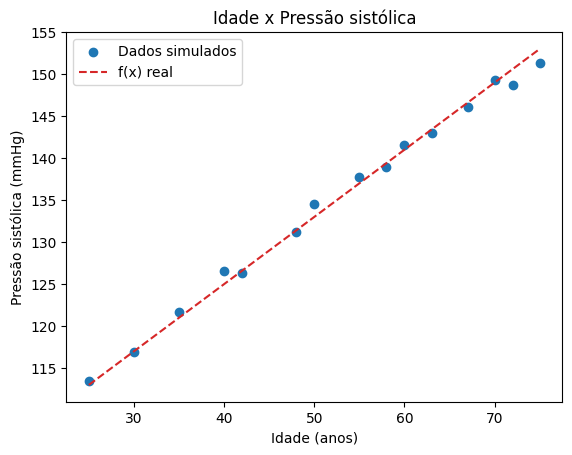

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fixa a semente para gerar os mesmos valores aleatórios a cada execução (opcional)
np.random.seed(42)

# Variável independente (x): Idades de 15 pacientes
idades = np.array([25, 30, 35, 40, 42, 48, 50, 55, 58, 60, 63, 67, 70, 72, 75])

# Função base f(x)
def f(x):
    return 0.8 * x + 93

# Termo de erro: Distribuição normal com média = 0 e variância = 1 (desvio padrão = 1)
erro = np.random.normal(loc=0.0, scale=1.0, size=len(idades))

# Geração de y = f(x) + erro
pressao_sistolica = f(idades) + erro

# Visualização
plt.scatter(idades, pressao_sistolica, color="tab:blue", label="Dados simulados")
plt.plot(idades, f(idades), color="tab:red", linestyle="--", label="f(x) real")
plt.xlabel("Idade (anos)")
plt.ylabel("Pressão sistólica (mmHg)")
plt.title("Idade x Pressão sistólica")
plt.legend()
plt.show()


## 3.2 Ajustando o modelo com `scikit-learn`

Na prática, não calculamos $b_0$ e $b_1$ na mão — usamos a classe `LinearRegression` do `scikit-learn`:

```python
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X, y)       # "aprende" a melhor reta a partir dos dados
modelo.predict(X_novo) # usa a reta aprendida para prever novos valores
```


Intercepto (b0): 94.86
Inclinação  (b1): 0.76


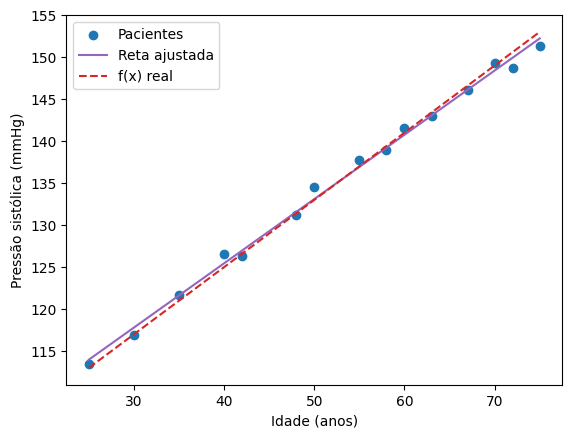

In [ ]:
from sklearn.linear_model import LinearRegression

X = idades.reshape(-1, 1)   # scikit-learn espera uma matriz (linhas = pacientes, colunas = variáveis)
y = pressao_sistolica

modelo = LinearRegression()
modelo.fit(X, y)

print("Intercepto (b0):", round(modelo.intercept_, 2))
print("Inclinação  (b1):", round(modelo.coef_[0], 2))

# Reta ajustada sobre os dados originais
plt.scatter(idades, pressao_sistolica, color="tab:blue", label="Pacientes")
plt.plot(idades, modelo.predict(X), color="tab:purple", label="Reta ajustada")
plt.plot(idades, f(idades), color="tab:red", linestyle="--", label="f(x) real")
plt.xlabel("Idade (anos)")
plt.ylabel("Pressão sistólica (mmHg)")
plt.legend()
plt.show()


## 3.3 A função de custo: "treinar" é otimizar

Quando dizemos que o modelo "aprende" a melhor reta, o que acontece por trás é uma **otimização**: o algoritmo busca os valores de $b_0$ e $b_1$ que **minimizam o erro** entre a previsão e o valor real.

A forma mais comum de medir esse erro é o **MSE** (*Mean Squared Error*, erro quadrático médio):

$$
MSE = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Essa é a **função de custo** (ou *loss function*). "Treinar um modelo" nada mais é do que **buscar os parâmetros que minimizam essa função**.


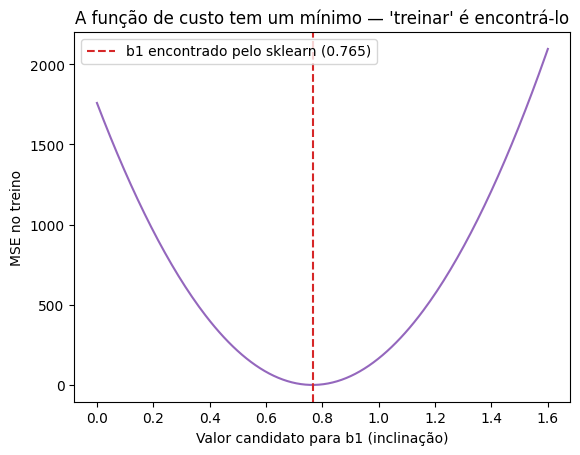

In [ ]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

b0_fixo = modelo.intercept_
candidatos_b1 = np.linspace(0, 1.6, 200)

erros = []
for b1 in candidatos_b1:
    previsao = b0_fixo + b1 * X.flatten()
    erros.append(mean_squared_error(y, previsao))

plt.plot(candidatos_b1, erros, color="tab:purple")
plt.axvline(modelo.coef_[0], color="tab:red", linestyle="--",
            label=f"b1 encontrado pelo sklearn ({modelo.coef_[0]:.3f})")
plt.xlabel("Valor candidato para b1 (inclinação)")
plt.ylabel("MSE no treino")
plt.title("A função de custo tem um mínimo — 'treinar' é encontrá-lo")
plt.legend()
plt.show()


A curva de erro forma um "vale", e o `b1` que o `scikit-learn` encontrou (linha vermelha) cai exatamente no ponto mais baixo — o **mínimo** da função de custo.

Modelos mais sofisticados (redes neurais, por exemplo) usam a mesma lógica, com funções de custo mais complexas e um algoritmo de busca chamado **gradiente descendente**, que "desce o morro" passo a passo até chegar perto do mínimo. A ideia central é sempre a mesma: **treinar = minimizar uma função de custo**.


## 3.4 Como interpretar o resultado

Depois de ajustar o modelo, três números merecem atenção:

- **Coeficiente ($b_1$):** "para cada ano a mais de idade, a pressão sistólica sobe, em média, $b_1$ mmHg". É a informação clinicamente mais interessante.
- **Intercepto ($b_0$):** valor previsto quando $x = 0$. Cuidado: em muitos casos clínicos $x = 0$ não faz sentido (idade 0?), então o intercepto é só uma peça matemática da reta, não uma previsão real.
- **$R^2$ (coeficiente de determinação):** vai de 0 a 1 e mede **quanto da variação dos dados o modelo consegue explicar**. $R^2 = 0.80$ significa que 80% da variação da pressão sistólica, nesse conjunto de dados, é explicada pela idade.

> ⚠️ **Correlação não é causalidade.** Um modelo pode mostrar uma relação forte entre duas variáveis sem que uma cause a outra — pode haver uma terceira variável por trás (um *confundidor*) explicando as duas. Regressão linear descreve **associação estatística**; conclusões causais em medicina exigem desenho de estudo adequado, não apenas um bom ajuste de reta. Exemplo: Caso faça uma regressão linear entre vendas de sorvete e ataques de tubarão, possivelmente você verá uma correlação (pois as pessoas tomam mais sorvete quando está calor, o que também as leva para a praia e simultaneamente atraem os tubarões para a orla) mas claramente não há causalidade.


O $R^2$ compara o erro do seu modelo com o erro de um modelo "ingênuo" que sempre prevê a média de $y$:

$$
R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2} = 1 - \frac{SQ_{res}}{SQ_{tot}}
$$

- $SQ_{res}$ (soma dos quadrados dos resíduos): o quanto sobra de erro depois do modelo.
- $SQ_{tot}$ (soma dos quadrados totais): o quanto de erro existiria se você só "chutasse" a média para todo mundo.

Se o modelo é tão ruim quanto chutar a média, $R^2 = 0$. Se o modelo acerta perfeitamente todos os pontos, $SQ_{res} = 0$ e $R^2 = 1$.


In [ ]:
r2 = modelo.score(X, y)
print(f"R² do modelo idade -> pressão sistólica: {r2:.3f}")
print(f"Interpretação: aproximadamente {r2*100:.1f}% da variação da pressão sistólica")
print("               observada nesses pacientes é explicada pela idade.")


R² do modelo idade -> pressão sistólica: 0.995
Interpretação: aproximadamente 99.5% da variação da pressão sistólica
               observada nesses pacientes é explicada pela idade.


## 3.5 O resumo estatístico completo (`statsmodels`)

O `scikit-learn` é ótimo para **prever**, mas entrega poucas estatísticas de inferência. Para uma leitura mais próxima do que vocês já viram em estatística — com erro padrão, intervalo de confiança e p-valor — usamos a biblioteca `statsmodels`:


In [ ]:
X_sm = sm.add_constant(idades)  # adiciona a coluna do intercepto (b0) explicitamente
modelo_sm = sm.OLS(pressao_sistolica, X_sm).fit()

print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     2753.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           1.61e-16
Time:                        16:08:20   Log-Likelihood:                -17.922
No. Observations:                  15   AIC:                             39.84
Df Residuals:                      13   BIC:                             41.26
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         94.8556      0.799    118.691      0.0

c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)


Essa saída parece assustadora na primeira vez, mas poucos números realmente importam no dia a dia. A tabela abaixo traduz os principais:

| Estatística | O que mede | Perto de 0 significa... | Perto de 1 (ou valor alto) significa... |
|---|---|---|---|
| **R-squared** | fração da variação de $y$ explicada pelo modelo | o modelo não explica quase nada da variação | o modelo explica quase toda a variação (ajuste muito bom) |
| **Adj. R-squared** | mesmo que R², mas penaliza adicionar variáveis que não ajudam | variáveis extras não estão contribuindo | mesmo penalizando, o modelo explica bem os dados |
| **coef** (de cada variável) | quanto $y$ muda, em média, para +1 unidade de $x$ | a variável quase não influencia $y$ | (valor grande, positivo ou negativo) a variável tem forte influência em $y$ |
| **std err** | incerteza na estimativa do coeficiente | estimativa bem precisa | estimativa pouco confiável — o coeficiente pode estar longe do valor real |
| **P>\|t\|** (p-valor do coeficiente) | probabilidade de ver esse coeficiente (ou mais extremo) se, na população real, ele fosse zero | forte evidência de que a variável **tem** efeito real (costuma-se considerar "significativo" abaixo de 0.05) | não há evidência estatística de que a variável tenha efeito sobre $y$ |
| **[0.025, 0.975]** | intervalo de confiança de 95% do coeficiente | intervalo estreito: estimativa precisa | intervalo largo, ou que inclui o zero: estimativa incerta (pode não haver efeito) |
| **Prob (F-statistic)** | p-valor do teste conjunto ("pelo menos uma variável tem efeito?") | pelo menos uma variável do modelo tem efeito real sobre $y$ | nenhuma variável do modelo parece ter efeito sobre $y$ |
| **Durbin-Watson** | autocorrelação dos resíduos (varia de 0 a 4; ideal ≈ 2) | perto de 0: resíduos fortemente autocorrelacionados (positivamente) — má notícia | perto de 4: autocorrelação negativa; o valor desejado é próximo de **2**, não de 1 |
| **Cond. No.** (número de condição) | o quanto as variáveis preditoras são redundantes entre si (multicolinearidade) | variáveis independentes entre si, coeficientes estáveis | valor muito alto (regra prática: acima de ~30) sugere multicolinearidade — coeficientes instáveis e difíceis de interpretar |

> 💡 Na prática: `scikit-learn` para **treinar e prever** (o foco de ML); `statsmodels` para **inspecionar e justificar** um modelo do ponto de vista estatístico (o foco de inferência). Muitos projetos usam os dois, cada um no seu momento.

> ⚠️ Um p-valor pequeno indica que o efeito **provavelmente não é zero** — não indica que o efeito é *grande* ou *clinicamente relevante*. Com muitos pacientes, até uma relação minúscula pode ter p-valor bem baixo.


### ✏️ Exercício 4

Você tem medidas de glicemia de jejum (mg/dL) e HbA1c (%, exame que reflete a glicemia média dos últimos 3 meses) de 20 pacientes:

```python
np.random.seed(7)
glicemia = np.random.uniform(70, 200, 20)
hba1c = 4 + 0.03 * glicemia + np.random.normal(0, 0.4, 20)
```

**🎯 Objetivo:**
1. Treine um `LinearRegression` para prever `hba1c` a partir de `glicemia`.
2. Calcule o MSE e R^2 imprima os dois valores.
3. Em um comentário, escreva se o modelo parece estar generalizando bem.


In [ ]:
np.random.seed(42)
glicemia = np.random.uniform(70, 200, 20)
hba1c = 4 + 0.03 * glicemia + np.random.normal(0, 0.4, 20)

# Continue o código

---
## ✅ Soluções dos exercícios em aula

Confira abaixo apenas **depois** de tentar. Existe mais de uma forma correta de resolver — se a sua for diferente mas funcionar, ótimo!


**Solução — Exercício 1**


In [ ]:
class Paciente:
    def __init__(self, nome, idade, peso, altura):
        self.nome = nome
        self.idade = idade
        self.peso = peso
        self.altura = altura

    def eh_maior_de_idade(self):
        return self.idade >= 18

jovem = Paciente("Lucas", 15, 60.0, 1.70)
print(jovem.nome, "é maior de idade?", jovem.eh_maior_de_idade())

Lucas é maior de idade? False


**Solução — Exercício 2**


In [ ]:
class Paciente:
    def __init__(self, nome, idade, peso, altura):
        self.nome = nome
        self.idade = idade
        self.peso = peso
        self.altura = altura

    def eh_maior_de_idade(self):
        return self.idade >= 18

jovem = Paciente("Lucas", 15, 60.0, 1.70)
print(jovem.nome, "é maior de idade?", jovem.eh_maior_de_idade())

Lucas é maior de idade? False


**Solução — Exercício 3**

In [ ]:
class SequenciaDNA:
    def __init__(self, bases):
        self.bases = bases.upper()

    def transcrever(self):
        """Transcrição simplificada: T -> U (uracila)."""
        return self.bases.replace("T", "U")

dna = SequenciaDNA("ATGC")
print("DNA:", dna.bases)
print("RNA:", dna.transcrever())

DNA: ATGC
RNA: AUGC


**Solução — Exercício 4**

In [ ]:
# # Dados de entrada
# np.random.seed(42)
# glicemia = np.random.uniform(70, 200, 20)
# hba1c = 4 + 0.03 * glicemia + np.random.normal(0, 0.4, 20)

# 1. Preparação das variáveis e treinamento da Regressão Linear
X = glicemia.reshape(-1, 1)
y = hba1c

model = LinearRegression()
model.fit(X, y)

# 2. Predição e cálculo das métricas (MSE e R²)
y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R²:  {r2:.4f}")

---
## 🎯 Resumo da aula

**Programação Orientada a Objetos**
- **Classe**: o molde; **objeto**: uma instância preenchida (o prontuário do paciente).
- **Atributos** guardam dados; **métodos** definem ações (`self` é o próprio objeto).
- **Métodos mágicos** (`__init__`, `__str__`, `__len__`, `__getitem__`, `__eq__`...) dão comportamentos naturais aos objetos.
- **Encapsulamento** protege os dados internos (`@property` + validação).
- **Abstração** expõe só o essencial e esconde os detalhes (classes abstratas com `abc`).
- **Herança** especializa uma classe reaproveitando outra; **polimorfismo** deixa o mesmo método se comportar conforme o tipo do objeto.

**Regressão Linear como porta de entrada**
- Modela a relação entre duas (ou mais) variáveis com uma reta: $y = b_0 + b_1 \cdot x$, ajustada pelo método dos **mínimos quadrados**.
- O que muda entre estatística e ML é o **objetivo**: inferência vs. **predição/generalização**.
- Coeficiente, intercepto e $R^2$ são as três peças-chave de interpretação — e **correlação não é causalidade**.